# Colab Demo Notebook: Gemini Notebook + Google Colab Workshop
Run the cells top to bottom in **Google Colab** (they use Colab-only features such as `!` shell commands and `google.colab.drive`).


## Cell 1: Architecture (remote Linux VM)
Shows that the code runs on a remote Colab VM, not on your laptop.


In [12]:
# The '!' Run's in: Colab cell (executes on the remote Colab Linux VM, not my laptop)
!cat /etc/os-release | head -2   # shows the VM's Linux distro
!nproc                            # CPU cores on the VM
!free -h | head -2                # system RAM on the VM

# Pre-installed data/ML stack: no pip install needed
import torch, pandas, sklearn
print(torch.__version__, pandas.__version__, sklearn.__version__)


PRETTY_NAME="Ubuntu 24.04.5 LTS"
NAME="Ubuntu"
2
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.7Gi       7.7Gi       3.6Mi       3.6Gi        11Gi
2.11.0+cpu 2.2.3 1.6.1


## Cell 2: Mount Drive and load data
Pre-authorize the Drive permission popup **before** presenting.
Edit `CSV_PATH` to point at the small CSV holding the numbers you verified via Gemini Notebook citations.

In [3]:
# Run in: Colab cell
from google.colab import drive
drive.mount('/content/drive')   # opens a permission popup - pre-authorize before presenting

Mounted at /content/drive


In [5]:
import pandas as pd

# Small CSV with the 4-6 numbers you verified via Notebook citations (edit the path)
CSV_PATH = '/content/drive/MyDrive/demo/ai_index_coding.csv'

try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    # Fallback dataset that ships with every Colab VM, so the demo never dead-ends
    df = pd.read_csv('/content/sample_data/california_housing_train.csv')

df.head()   # show the first rows

,model,score_pct,source
0,Claude 4.5 Opus (high reasoning),76.8,AI Index 2026 Fig 2.5.1 p.101
1,MiniMax M2.5 (high reasoning),75.8,AI Index 2026 Fig 2.5.1 p.101
2,Gemini 3 Flash (high reasoning),75.8,AI Index 2026 Fig 2.5.1 p.101
3,Claude Opus 4.6,75.6,AI Index 2026 Fig 2.5.1 p.101
4,GPT-5-2 Codex,72.8,AI Index 2026 Fig 2.5.1 p.101


## Cell 3: Planted error (demo "Explain error")
This cell **fails on purpose**. Run it, then click the **Explain error** button under the output.
If the button does not appear for this error type, swap in a different deliberate mistake.

In [ ]:
# Run in: Colab cell - deliberate typo to demo "Explain error"
# (assumes your CSV column is named score_pct; the misspelling below triggers a KeyError)
df['scor_pct'].max()


KeyError: 'scor_pct'

**1. Prompt: SWE-bench Verified, top 10 models (AI Index 2026)**

Plot df as a horizontal bar chart of score_pct by model, sorted so the highest score is at the top. Start the x-axis at 0, label each bar with its value, and add a text annotation showing the gap between the highest and lowest score. Title it "SWE-bench Verified, top 10 models (AI Index 2026)".

/tmp/ipykernel_677/4257126914.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score_pct', y='model', data=df_sorted, palette='viridis')


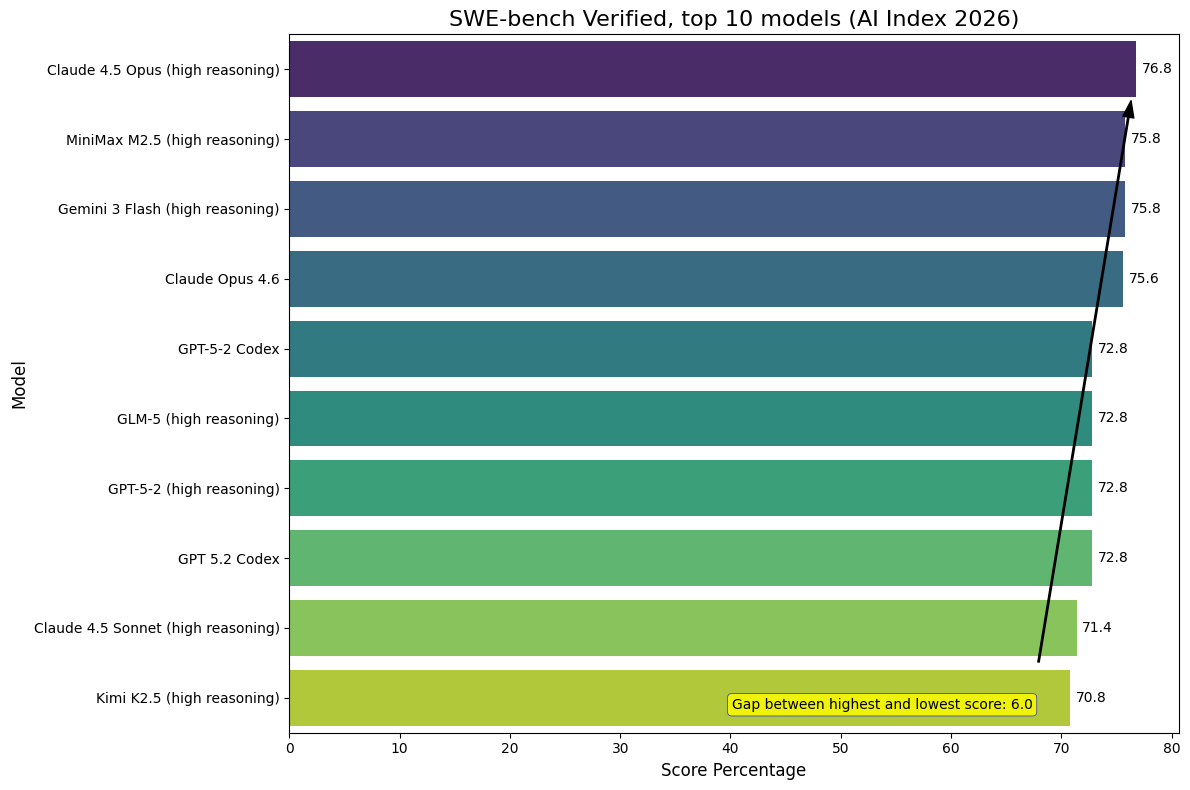

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by score_pct in descending order
df_sorted = df.sort_values(by='score_pct', ascending=False)

# Set the figure size for better readability
plt.figure(figsize=(12, 8))

# Create the horizontal bar chart
sns.barplot(x='score_pct', y='model', data=df_sorted, palette='viridis')

# Set the x-axis to start at 0
plt.xlim(left=0)

# Add labels to each bar
for index, row in df_sorted.iterrows():
    plt.text(row.score_pct + 0.5, index, f'{row.score_pct:.1f}', color='black', ha="left", va="center")

# Calculate the gap between the highest and lowest score
highest_score = df_sorted['score_pct'].max()
lowest_score = df_sorted['score_pct'].min()
gap = highest_score - lowest_score

# Add text annotation for the gap
plt.annotate(
    f'Gap between highest and lowest score: {gap:.1f}',
    xy=(highest_score, 0),
    xytext=(highest_score * 0.7, len(df_sorted) * 0.9), # Position the annotation dynamically
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=0.5, alpha=0.8),
    horizontalalignment='center',
    verticalalignment='top'
)

# Add title and labels
plt.title("SWE-bench Verified, top 10 models (AI Index 2026)", fontsize=16)
plt.xlabel("Score Percentage", fontsize=12)
plt.ylabel("Model", fontsize=12)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Show the plot
plt.show()


**2. Ties and tiers (recommended)**

Using df, make a horizontal bar chart of score_pct by model with the highest score at the top. Color the bars by score so models with the same score share a color, and add a legend. Label each bar with its value and add a note showing how many models are tied at each shared score. Title it "Ranked by score, but many are tied".

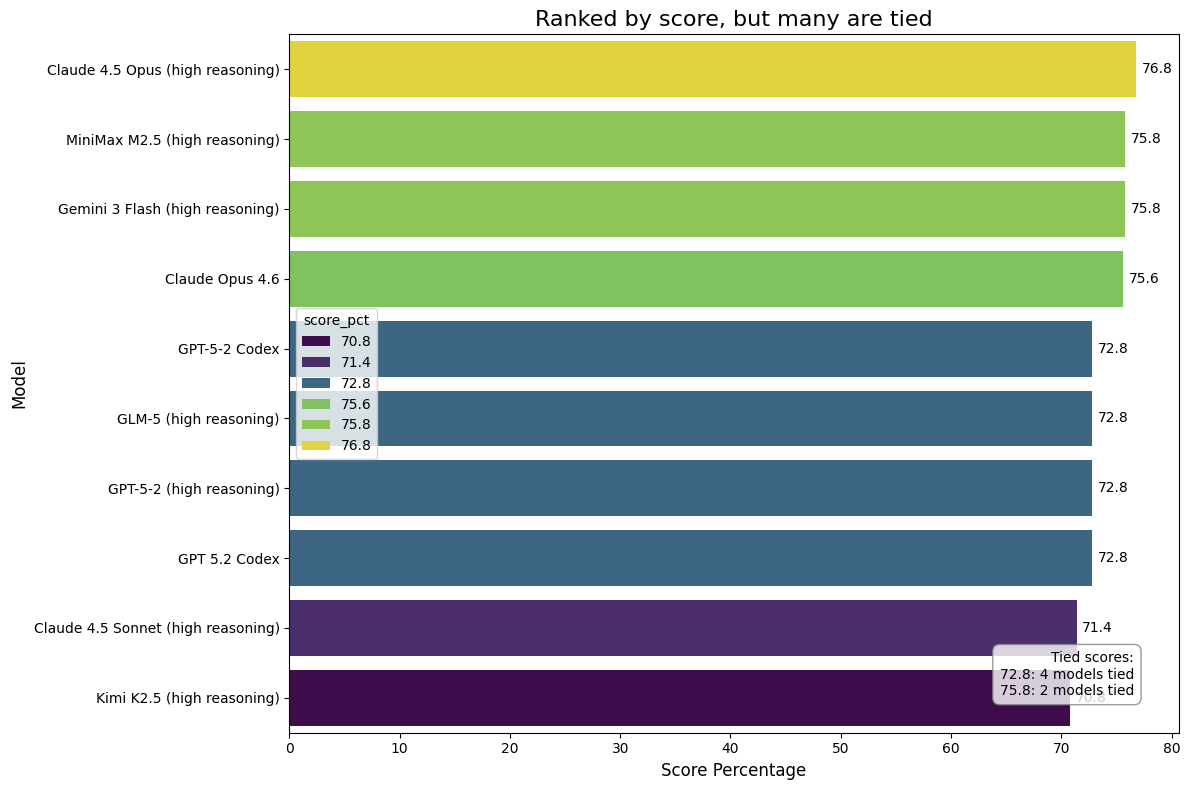

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by score_pct in descending order
df_sorted = df.sort_values(by='score_pct', ascending=False)

# Set the figure size for better readability
plt.figure(figsize=(12, 8))

# Create the horizontal bar chart, coloring bars by score_pct and adding a legend
sns.barplot(x='score_pct', y='model', data=df_sorted, hue='score_pct', palette='viridis', legend='full')

# Set the x-axis to start at 0
plt.xlim(left=0)

# Add labels to each bar
for index, row in df_sorted.iterrows():
    plt.text(row.score_pct + 0.5, index, f'{row.score_pct:.1f}', color='black', ha="left", va="center")

# Calculate counts for tied scores
score_counts = df_sorted['score_pct'].value_counts()
tied_models_str = []
for score, count in score_counts.items():
    if count > 1:
        tied_models_str.append(f'{score:.1f}: {count} models tied')

# Add annotation for tied scores if any exist
if tied_models_str:
    tied_text = 'Tied scores:\n' + '\n'.join(tied_models_str)
    # Position the text annotation in the bottom-right corner of the plot
    plt.text(0.95, 0.05, tied_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', lw=1, alpha=0.8))

# Add title and labels
plt.title("Ranked by score, but many are tied", fontsize=16)
plt.xlabel("Score Percentage", fontsize=12)
plt.ylabel("Model", fontsize=12)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Show the plot
plt.show()


**3. Axis comparison**

Using df, make two horizontal bar charts side by side with the same model order and the highest score at the top. Left chart: x-axis from 0 to 100, titled "Zero-based axis". Right chart: x-axis from 70 to 77, titled "Zoomed axis". Label each bar with its value and hide the model names on the right chart. Add the overall title "Same data, two axes". For left chart have model name INSIDE bar and score OUTSIDE bar

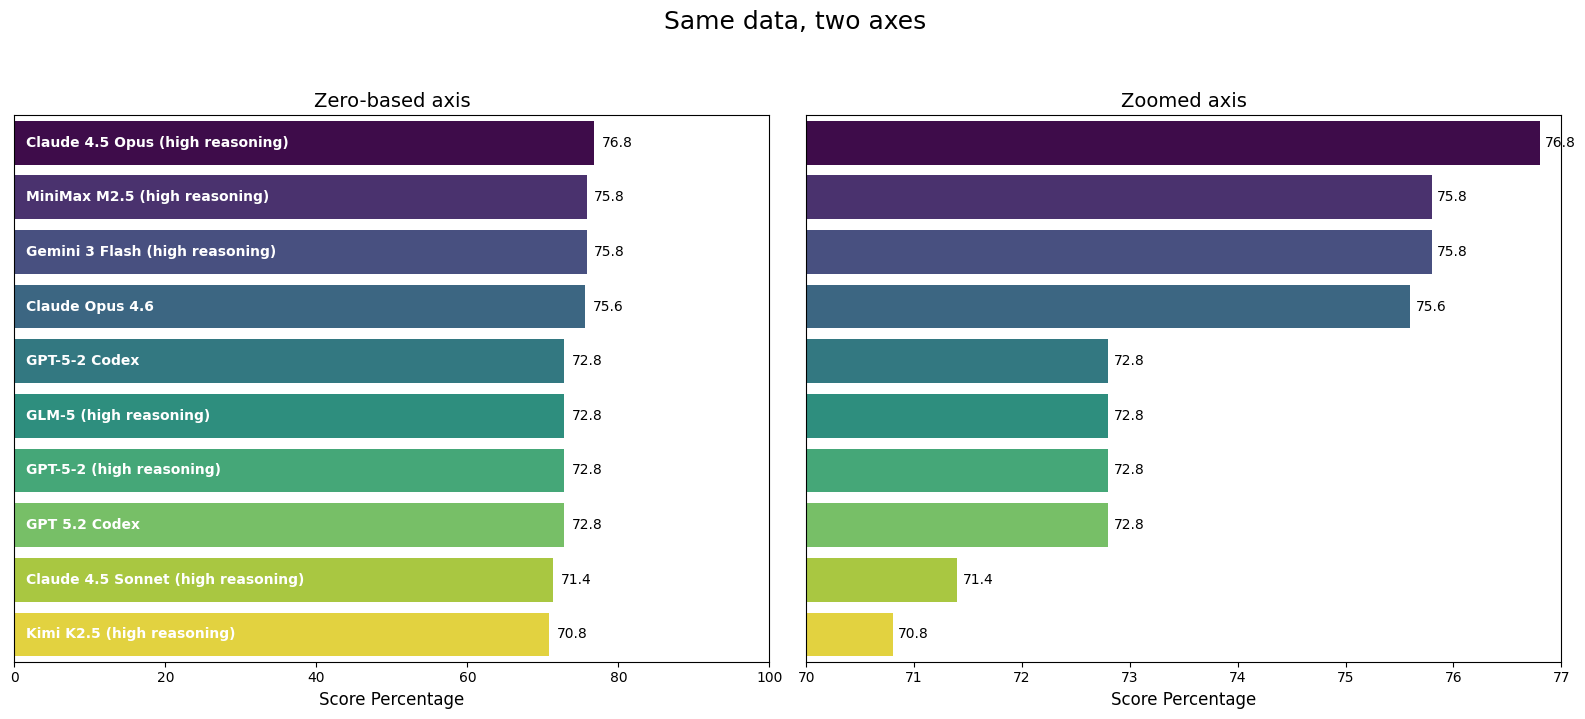

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CHANGE: Reset index so positions are 0, 1, 2...
df_sorted = df.sort_values(by='score_pct', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle("Same data, two axes", fontsize=18, y=1.02)

# --- Left Chart: Zero-based axis ---
# 2. CHANGE: y is now df_sorted.index instead of 'model'
sns.barplot(x='score_pct', y=df_sorted.index, data=df_sorted, orient='h', hue=df_sorted.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Zero-based axis", fontsize=14)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Score Percentage", fontsize=12)
axes[0].set_ylabel("")  # CHANGE: Clear "Model" label

# 3. CHANGE: Hide y-ticks completely so left margin is 0
axes[0].tick_params(axis='y', left=False, labelleft=False)

# 4. CHANGE: Draw model name INSIDE bar and score OUTSIDE bar
for i, row in df_sorted.iterrows():
    # Model name inside the left edge of the colored bar:
    axes[0].text(1.5, i, row['model'], color='white', ha="left", va="center", fontweight='bold', fontsize=10)
    # Score number outside the right edge:
    axes[0].text(row['score_pct'] + 1.0, i, f"{row['score_pct']:.1f}", color='black', ha="left", va="center", fontsize=10)

# --- Right Chart: Zoomed axis ---
sns.barplot(x='score_pct', y=df_sorted.index, data=df_sorted, orient='h', hue=df_sorted.index, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title("Zoomed axis", fontsize=14)
axes[1].set_xlim(70, 77)
axes[1].set_xlabel("Score Percentage", fontsize=12)
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', left=False, labelleft=False)

for i, row in df_sorted.iterrows():
    axes[1].text(row['score_pct'] + 0.05, i, f"{row['score_pct']:.1f}", color='black', ha="left", va="center", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


**4. Adjacent gaps (backup)**

Using df sorted by score_pct from highest to lowest, plot score against rank as a line with markers. Label the score difference between each pair of adjacent models, and start the y-axis at 0.

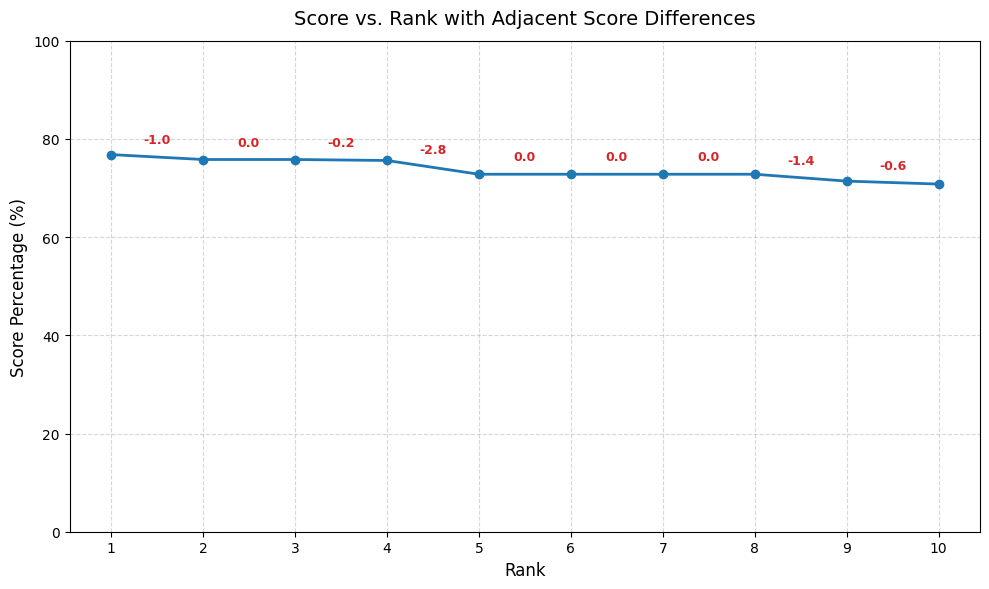

In [11]:
import matplotlib.pyplot as plt

# 1. Sort dataframe by score_pct descending and assign 1-based ranks
df_sorted = df.sort_values(by='score_pct', ascending=False).reset_index(drop=True)
df_sorted['rank'] = range(1, len(df_sorted) + 1)

# 2. Create the figure and plot the score vs rank line
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_sorted['rank'], df_sorted['score_pct'], marker='o', linewidth=2, color='#1f77b4', markersize=6)

# 3. Annotate the score difference (drop) between adjacent models
for i in range(len(df_sorted) - 1):
    r1, r2 = df_sorted.loc[i, 'rank'], df_sorted.loc[i + 1, 'rank']
    s1, s2 = df_sorted.loc[i, 'score_pct'], df_sorted.loc[i + 1, 'score_pct']
    diff = s1 - s2

    # Calculate midpoint between the two adjacent points
    mid_x = (r1 + r2) / 2
    mid_y = (s1 + s2) / 2

    # Label the delta (Δ)
    ax.annotate(
        f'-{diff:.1f}' if diff > 0 else '0.0',
        xy=(mid_x, mid_y),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        color='#d62728',
        fontweight='bold'
    )

# 4. Configure axes and labels
ax.set_ylim(bottom=0, top=100)
ax.set_xticks(df_sorted['rank'])
ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Score Percentage (%)', fontsize=12)
ax.set_title('Score vs. Rank with Adjacent Score Differences', fontsize=14, pad=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**CPU vs. GPU seconds, the speedup**

Change the runtime to

In [1]:
# Run in: Colab notebook cell (Runtime > Change runtime type > T4 GPU)
import time, torch

print("=" * 50)
print("GPU TIMING TEST — START")
print("=" * 50)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
print()

n = 4096
a_cpu = torch.randn(n, n)   # two large random matrices on CPU
b_cpu = torch.randn(n, n)

# Time a matrix multiply on CPU
t0 = time.time()
_ = a_cpu @ b_cpu
cpu_s = time.time() - t0

# Move to GPU (this line fails on a CPU-only runtime)
a_gpu, b_gpu = a_cpu.cuda(), b_cpu.cuda()
_ = a_gpu @ b_gpu           # warm-up: first CUDA call has startup overhead
torch.cuda.synchronize()

t0 = time.time()
_ = a_gpu @ b_gpu
torch.cuda.synchronize()    # wait for the GPU to finish before stopping the clock
gpu_s = time.time() - t0

print("=" * 50)
print("GPU TIMING TEST — RESULTS")
print("=" * 50)
print(f"Matrix size:     {n} x {n}")
print(f"CPU time:        {cpu_s:.4f} sec")
print(f"GPU time:        {gpu_s:.4f} sec")
print(f"Speedup:         {cpu_s / gpu_s:.1f}x faster on GPU")
print("=" * 50)

GPU TIMING TEST — START
CUDA available: True
GPU name: Tesla T4

GPU TIMING TEST — RESULTS
Matrix size:     4096 x 4096
CPU time:        2.5324 sec
GPU time:        0.0394 sec
Speedup:         64.2x faster on GPU
